# 인천공항 이용자수 분석 및 예측

1. https://kosis.kr/search/search.do 접속.
2. 출입국 항국/내외국인/성별 국제이동(연간) 검색.
3. 항목(우측사이드): 입국자, 출국자, 인천공항, 내외국인, 남여, 기간 선택.
4. 피봇테이블 설정.
   
   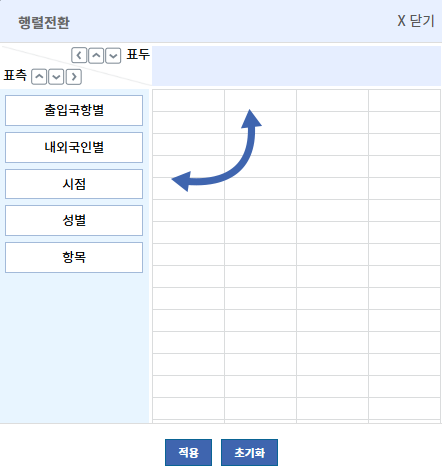   

/opt/conda/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/conda/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Text(0.2, 0.4, '한글')

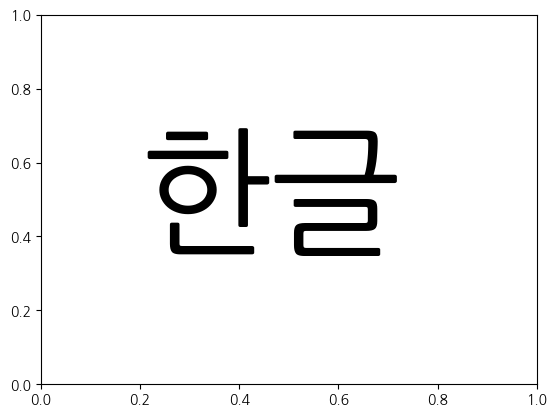

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')
plt.text(0.2,0.4, '한글', size=100)

In [2]:
file_path = "./dataset/인천공항이용자수20260605_lite.csv"
raw = pd.read_csv(file_path, encoding="EUC-KR")  # UTF8
raw.head(10)

,출입국항별,내외국인별,시점,항목,성별,데이터
0,인천공항,내국인,2001,입국자,남자,70444
1,인천공항,내국인,2001,입국자,여자,69542
2,인천공항,내국인,2001,출국자,남자,96551
3,인천공항,내국인,2001,출국자,여자,103115
4,인천공항,내국인,2002,입국자,남자,101032
5,인천공항,내국인,2002,입국자,여자,102880
6,인천공항,내국인,2002,출국자,남자,124319
7,인천공항,내국인,2002,출국자,여자,136808
8,인천공항,내국인,2003,입국자,남자,102093
9,인천공항,내국인,2003,입국자,여자,106827


In [3]:
# 컬럼명 바꾸기
ex1_data = raw.copy()
# 방법1
# ex1_data.columns = ['airport', 'type1', 'year', 'gender', 'type2', 'value']
# 방법2
ex1_data.rename(columns={'출입국항별':'airport', '내외국인별':'type1', '시점':'year', '성별':'gender', '항목':'type2', '데이터':'value'}, inplace=True)
ex1_data.columns

Index(['airport', 'type1', 'year', 'type2', 'gender', 'value'], dtype='str')

In [4]:
# 필터제작
filter1 = ex1_data['type1'] == '외국인'
ex2_data = ex1_data[filter1].copy()
ex2_data.head()

,airport,type1,year,type2,gender,value
96,인천공항,외국인,2001,입국자,남자,60699
97,인천공항,외국인,2001,입국자,여자,47963
98,인천공항,외국인,2001,출국자,남자,44548
99,인천공항,외국인,2001,출국자,여자,28348
100,인천공항,외국인,2002,입국자,남자,77745


In [5]:
# 년도별 통계
ex1_total = ex1_data.groupby('year')['value'].sum().reset_index(name = 'total')
ex1_total

,year,total
0,2001,521210
1,2002,697631
2,2003,747272
3,2004,769912
4,2005,991717
5,2006,996275
6,2007,1012415
7,2008,1080247
8,2009,1009778
9,2010,1019086


In [6]:
filter2_in = ex2_data['type2'] == '입국자'
ex2_in = ex2_data[filter2_in]
filter2_out = ex2_data['type2'] == '출국자'
ex2_out = ex2_data[filter2_out]
ex2_in = ex2_in.groupby('year')['value'].sum().reset_index(name="intotal")
ex2_out = ex2_out.groupby('year')['value'].sum().reset_index(name="outtotal")

<Axes: title={'center': '2015 ~ 2024년 인천공항 입국 외국인 차트'}>

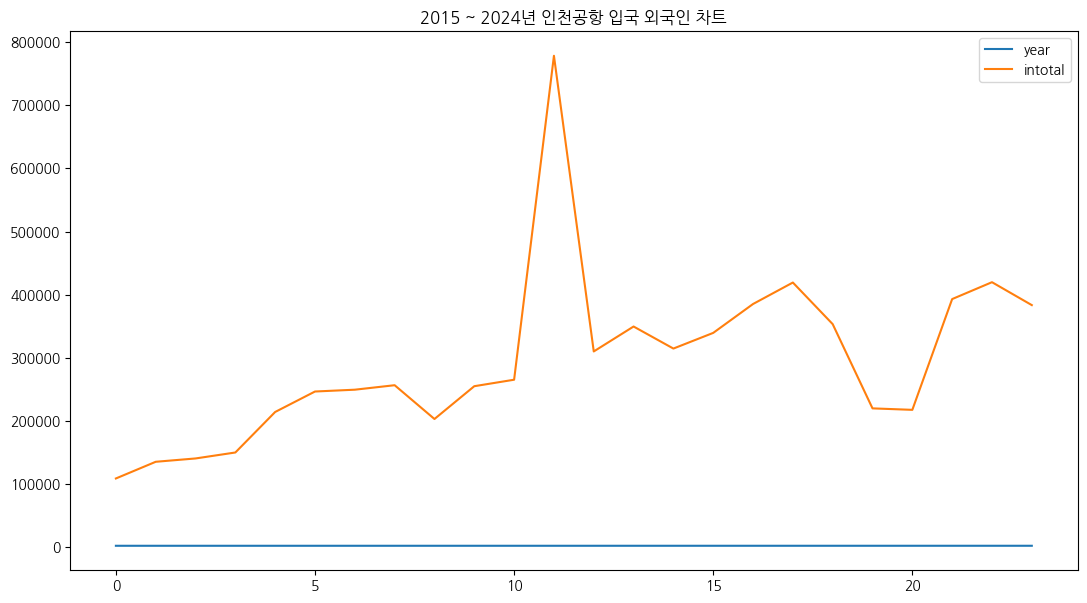

In [7]:
ex2_in.plot(figsize=(13,7), title="2015 ~ 2024년 인천공항 입국 외국인 차트")

<Axes: title={'center': '2015 ~ 2024년 인천공항 출국 외국인 차트'}>

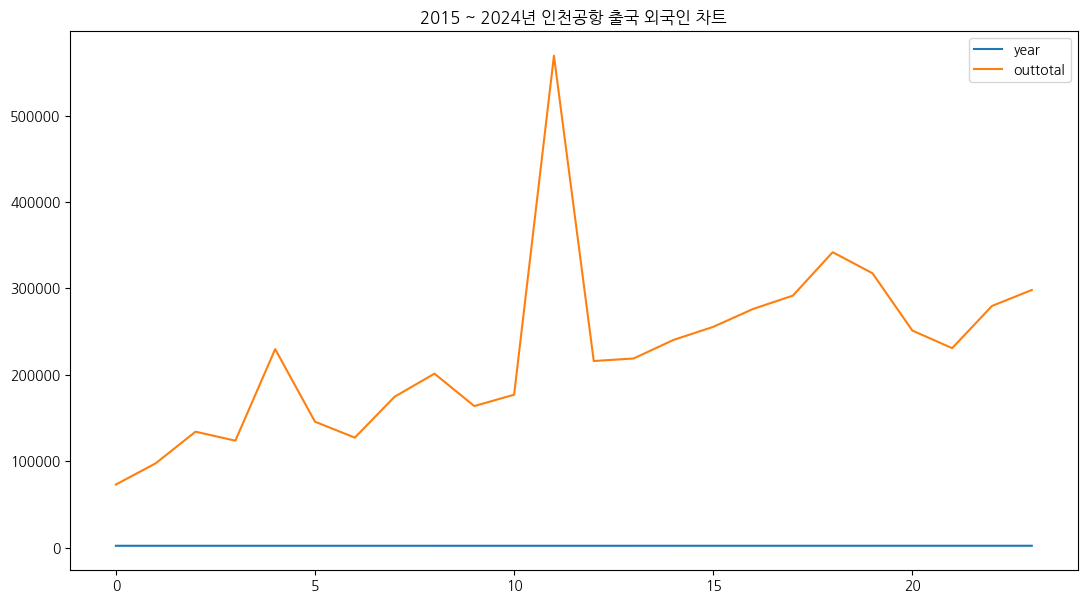

In [8]:
ex2_out.plot(figsize=(13,7), title="2015 ~ 2024년 인천공항 출국 외국인 차트")

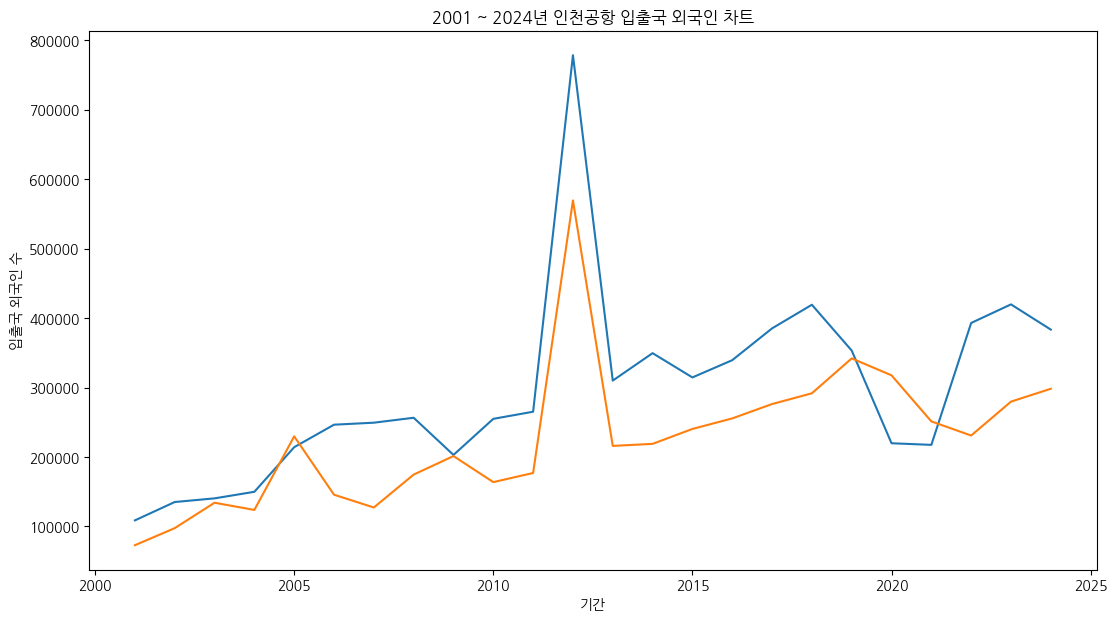

In [9]:
# ex2_in, ex2_out
plt.figure(figsize=(13,7))
plt.plot(ex2_in['year'], ex2_in['intotal'])
plt.plot(ex2_out['year'], ex2_out['outtotal'])
plt.title("2001 ~ 2024년 인천공항 입출국 외국인 차트")
plt.xlabel("기간")
plt.ylabel("입출국 외국인 수")
plt.show()

In [10]:
# !pip install prophet
# !pip install plotly

In [11]:
from prophet import Prophet # time은 ds, value는 y 전처리필요

In [12]:
pro_data = ex2_in.copy()
pro_data['year'] = pd.to_datetime(pro_data['year'], format="%Y")
pro_data = pro_data.rename(columns={'year':'ds','intotal':'y'})
pro_data

,ds,y
0,2001-01-01,108662
1,2002-01-01,135099
2,2003-01-01,140375
3,2004-01-01,149826
4,2005-01-01,214051
5,2006-01-01,246453
6,2007-01-01,249330
7,2008-01-01,256440
8,2009-01-01,202894
9,2010-01-01,254870


In [13]:
m = Prophet()
m.fit(pro_data)

03:07:27 - cmdstanpy - INFO - Chain [1] start processing
03:07:27 - cmdstanpy - INFO - Chain [1] done processing


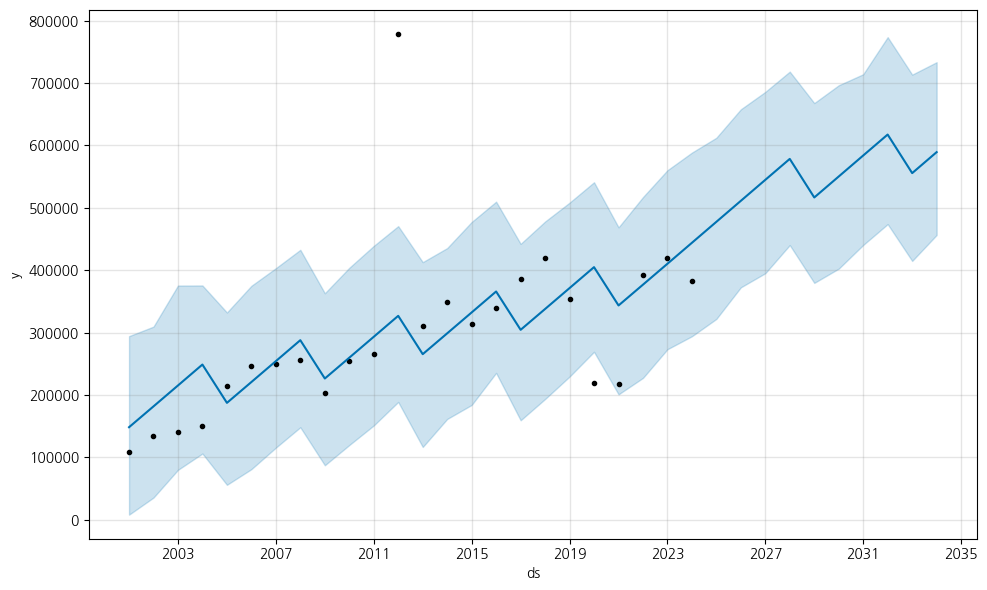

In [14]:
future = m.make_future_dataframe(periods=10, freq='YE')
forecast = m.predict(future)
fig1 = m.plot(forecast)
plt.show()

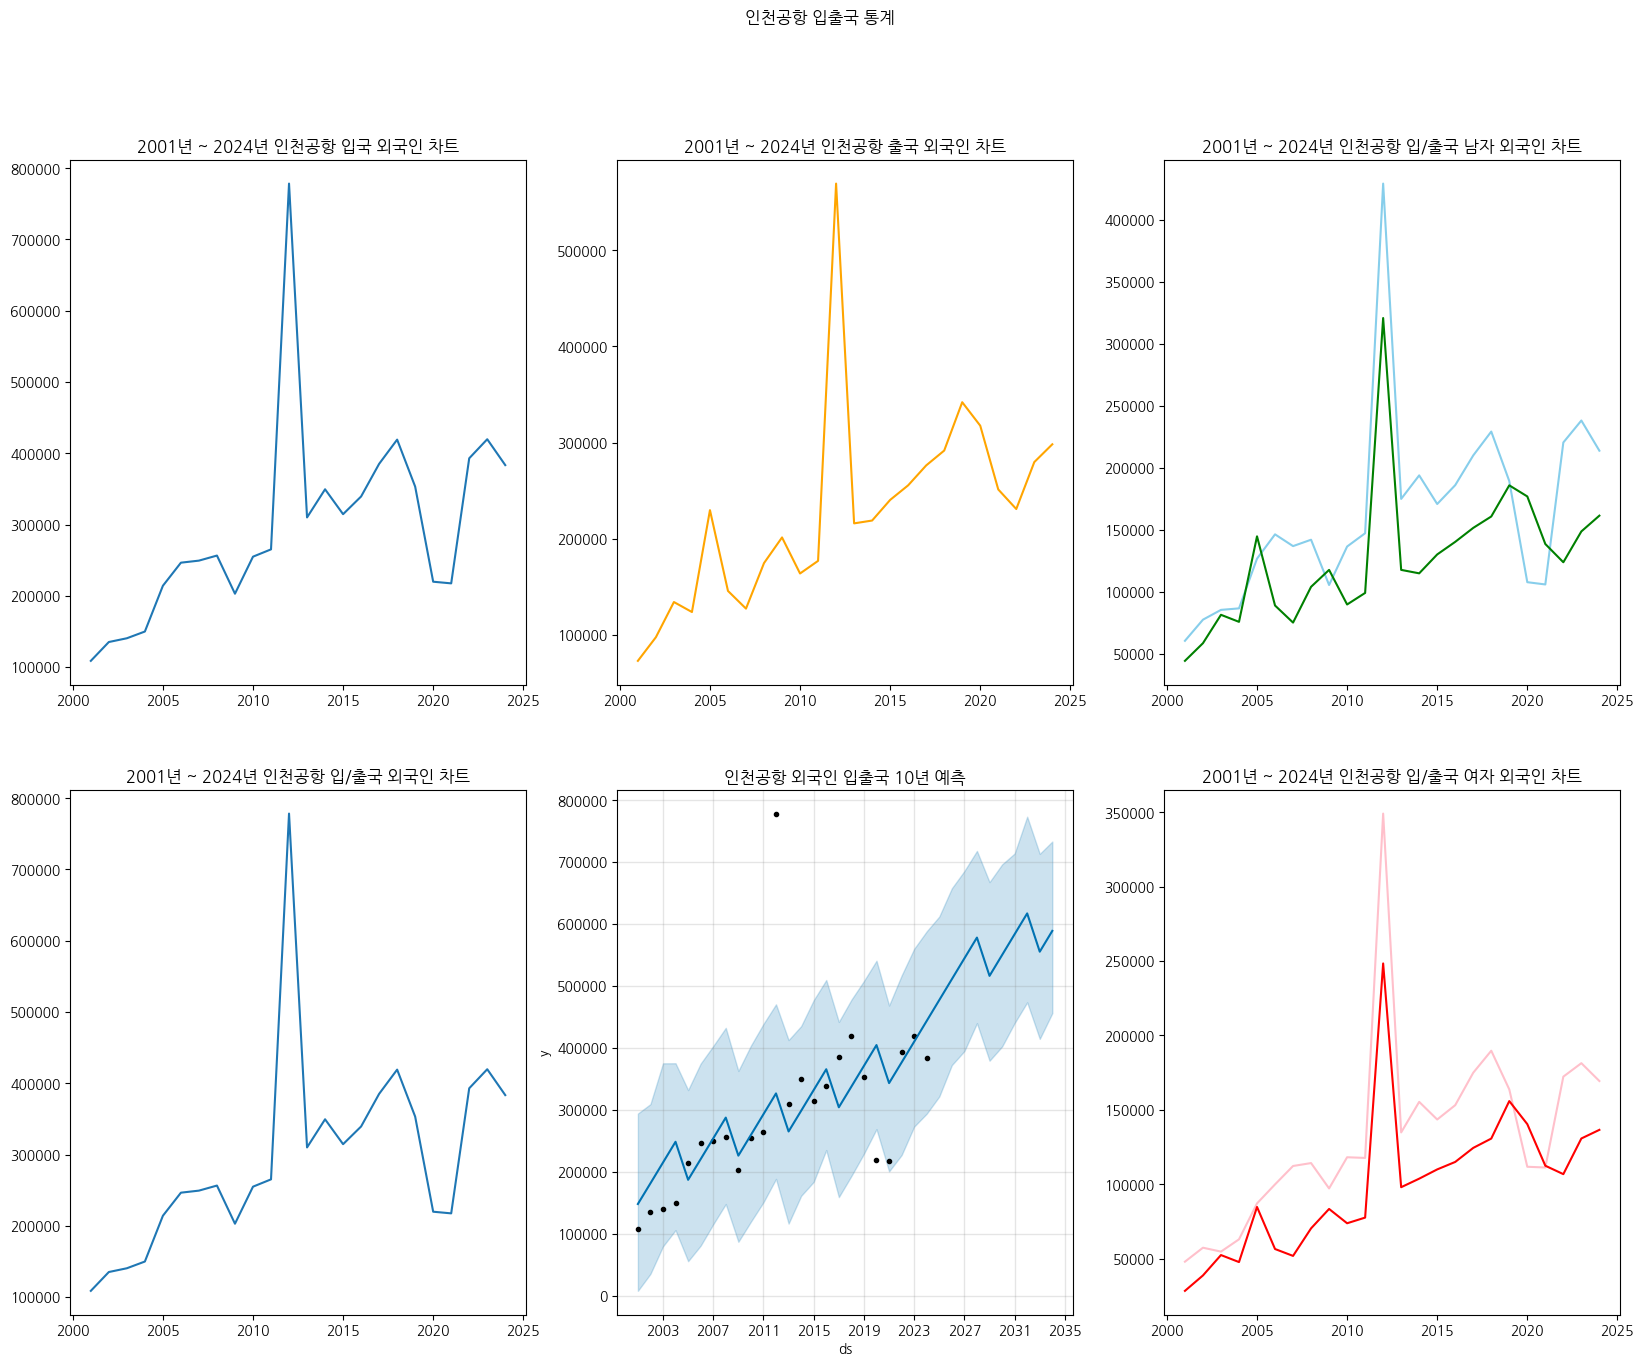

In [41]:
in_male   = ex2_data[(ex2_data['type2'] == '입국자') & (ex2_data['gender'] == '남자')]
in_female = ex2_data[(ex2_data['type2'] == '입국자') & (ex2_data['gender'] == '여자')]
out_male  = ex2_data[(ex2_data['type2'] == '출국자') & (ex2_data['gender'] == '남자')]
out_female= ex2_data[(ex2_data['type2'] == '출국자') & (ex2_data['gender'] == '여자')]

in_male   = in_male.groupby('year')['value'].sum().reset_index(name="inmale")
in_female = in_female.groupby('year')['value'].sum().reset_index(name="infemale")
out_male  = out_male.groupby('year')['value'].sum().reset_index(name="outmale")
out_female= out_female.groupby('year')['value'].sum().reset_index(name="outfemale")

fig, ax = plt.subplots(2,3,figsize=(20,15))
ax[0,0].plot(ex2_in['year'],ex2_in['intotal'])
ax[0,1].plot(ex2_out['year'],ex2_out['outtotal'], color='orange')
ax[1,0].plot(ex2_in['year'],ex2_in['intotal'])
m.plot(forecast, ax=ax[1,1])

ax[0,2].plot(in_male['year'], in_male['inmale'], color="skyblue")
ax[0,2].plot(out_male['year'],out_male['outmale'], color="green")
ax[1,2].plot(in_female['year'],in_female['infemale'], color="pink")
ax[1,2].plot(out_female['year'],out_female['outfemale'], color="red")

ax[0,0].set_title("2001년 ~ 2024년 인천공항 입국 외국인 차트")
ax[0,1].set_title("2001년 ~ 2024년 인천공항 출국 외국인 차트")
ax[1,0].set_title("2001년 ~ 2024년 인천공항 입/출국 외국인 차트")
ax[1,1].set_title("인천공항 외국인 입출국 10년 예측")

ax[0,2].set_title("2001년 ~ 2024년 인천공항 입/출국 남자 외국인 차트")
ax[1,2].set_title("2001년 ~ 2024년 인천공항 입/출국 여자 외국인 차트")

fig.suptitle('인천공항 입출국 통계')
plt.savefig("./인천공학 입출국 통계.png")
plt.show()